In [ ]:
#0-1　基本設定

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

import os

from google.colab import drive
drive.mount('/content/drive')

!pip install -q japanize-matplotlib
import japanize_matplotlib

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#0-2　データ復元

SAVE_DIR = "/content/drive/MyDrive/home_credit_models_gpu"
SAVE_DIR_CAT = os.path.join(SAVE_DIR, "home_credit_models_gpu_CAT")

# --- FE2データ（AMT_CREDIT取得用） ---
train = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/Kaggle/home-credit-default-risk/加工データ/03FE2/train_FE2.zstd.parquet')

# --- OOF予測値の復元 ---
oof_lgbm_df = pd.read_parquet(os.path.join(SAVE_DIR, "oof_lgbm.parquet"))
oof_lgbm = oof_lgbm_df["oof_lgbm"].values
y = oof_lgbm_df["TARGET"].values

oof_cb_df = pd.read_parquet(os.path.join(SAVE_DIR_CAT, "oof_catboost.parquet"))
oof_cb = oof_cb_df["oof_catboost"].values

# --- アンサンブル重み（ANALYZEの結果） ---
w_lgbm = 0.59
y_prob = oof_lgbm * w_lgbm + oof_cb * (1 - w_lgbm)
amt_credit = train['AMT_CREDIT'].values

ensemble_auc = roc_auc_score(y, y_prob)
print(f"Ensemble OOF AUC: {ensemble_auc:.5f}")
print(f"データ件数: {len(y):,}")
print(f"デフォルト率: {y.mean():.4f} ({y.sum():,}件 / {len(y):,}件)")
print(f"融資総額: {amt_credit.sum():,.0f}")

Ensemble OOF AUC: 0.79411
データ件数: 307,511
デフォルト率: 0.0807 (24,825.0件 / 307,511件)
融資総額: 184,207,084,196


In [ ]:
#1-1　サマリー
'''

■ モデル概要
  Ensemble（LGBM 0.59 + CatBoost 0.41）OOF AUC: 0.79411
  学習データ: 307,511件、特徴量: 669列

■ 改善プラン
　ベースライン（元データ：申請を承認し、融資を行ったデータ）を一次審査とし、
  1次審査通過者に対して、当該モデルの正常Precision 95%ライン（閾値≒0.24）をスクリーニング試験運用を推奨。
  申請の約86%を自動承認し、残り約14%を人間が二次審査する。

■ 導入効果（本ノートブックで試算）
  コスト試算はLGD・利益率・審査単価をパラメータ化して実施。
  「貸倒防止額 > 機会損失 + 審査コスト」が成立する条件を提示。

■ 制約
  - 通貨単位が不明のため、相対比較で提示
  - 督促コスト等の間接費用はデータから算出不可
  - ORGANIZATION_TYPEの過学習リスクあり（SHAP分析で指摘済み）
=================================================================
'''

'\n\n■ モデル概要\n  Ensemble（LGBM 0.59 + CatBoost 0.41）OOF AUC: 0.79411\n  学習データ: 307,511件、特徴量: 669列\n \n■ 提案\n  正常Precision 95%ライン（閾値≒0.24）での運用を推奨。\n  申請の約86%を自動承認し、残り約14%を人間が二次審査する。\n \n■ 導入効果（本ノートブックで試算）\n  コスト試算はLGD・利益率・審査単価をパラメータ化して実施。\n  「貸倒防止額 > 機会損失 + 審査コスト」が成立する条件を提示。\n \n■ 制約\n  - 通貨単位が不明のため、相対比較で提示\n  - 督促コスト等の間接費用はデータから算出不可\n  - ORGANIZATION_TYPEの過学習リスクあり（SHAP分析で指摘済み）\n=================================================================\n'

In [ ]:
#2-1　モデル性能サマリ（ANALYZEからの引用）
'''
■ 性能指標（ANALYZEノートブックより）
  - Ensemble OOF AUC: 0.79411
  - SHAP TOP1: EXT_SOURCES_GEOM_MEAN（自作の幾何平均特徴量）
  - F1最適閾値: 0.3000（Macro-F1: 0.6383）
  - F1最適閾値でのデフォルトPrecision: 31.8%

■ 自動承認率（正常Precisionライン別）
  - 95% → 86.1%自動承認（閾値: 0.2400）
  - 96% → 76.9%（閾値: 0.1700）
  - 97% → 62.6%（閾値: 0.1100）
  - 98% → 39.4%（閾値: 0.0600）
  - 99% → 15.6%（閾値: 0.0300）
'''

'\n■ 性能指標（ANALYZEノートブックより）\n  - Ensemble OOF AUC: 0.79411\n  - SHAP TOP1: EXT_SOURCES_GEOM_MEAN（自作の幾何平均特徴量）\n  - F1最適閾値: 0.3000（Macro-F1: 0.6383）\n  - F1最適閾値でのデフォルトPrecision: 31.8%\n \n■ 自動承認率（正常Precisionライン別）\n  - 95% → 86.1%自動承認（閾値: 0.2400）\n  - 96% → 76.9%（閾値: 0.1700）\n  - 97% → 62.6%（閾値: 0.1100）\n  - 98% → 39.4%（閾値: 0.0600）\n  - 99% → 15.6%（閾値: 0.0300）\n'

In [ ]:
#3-1　運用フロー（3分岐方式）
'''
  申請承認(現状の審査通過者)
    │
    ▼
  モデルスコアリング（Ensemble予測確率）
    │
    ├─ スコア < 閾値T ──→ 【自動承認】（約86%）
    │                      正常Precision ≥ 95%
    │
    └─ スコア ≥ 閾値T ──→ 【人間二次審査】（約14%）
                            │
                            ├─ 審査通過 → 承認
                            └─ 審査却下 → 融資拒否
=================================================================
補足：
  - 推奨閾値T = 0.24（正常Precision ≥ 95%ライン）
  - デフォルト判定のPrecisionが27.3%（閾値0.24時）であるため、
    モデル単独での自動却下は推奨しない。
  - 人間審査により、FP（誤検知）の救済とTP（正検知）の確認を行う。
  - 閾値Tは正常Precision目標に応じて調整可能。
=================================================================
'''

'\n  申請受付\n    │\n    ▼\n  モデルスコアリング（Ensemble予測確率）\n    │\n    ├─ スコア < 閾値T ──→ 【自動承認】（約86%）\n    │                      正常Precision ≥ 95%\n    │\n    └─ スコア ≥ 閾値T ──→ 【人間二次審査】（約14%）\n                            │\n                            ├─ 審査通過 → 承認\n                            └─ 審査却下 → 融資拒否\n=================================================================\n補足：\n  - 推奨閾値T = 0.24（正常Precision ≥ 95%ライン）\n  - デフォルト判定のPrecisionが27.3%（閾値0.24時）であるため、\n    モデル単独での自動却下は推奨しない。\n  - 人間審査により、FP（誤検知）の救済とTP（正検知）の確認を行う。\n  - 閾値Tは正常Precision目標に応じて調整可能。\n=================================================================\n'

In [ ]:
#4-1　コスト試算　パラメータ設定
'''
■ パラメータ定義
  LGD（Loss Given Default）：デフォルト時に融資額の何%が損失となるか
  利益率：正常完済時に融資額の何%が利益となるか（金利収入等）
  審査単価：人間が1件審査するのにかかるコスト

■ 注意事項
  - 通貨単位が不明のため、融資額（AMT_CREDIT）ベースの相対値で算出
  - LGD・利益率は業界一般値の範囲でパラメータ化
  - 督促・回収コスト等の間接費用はデータから算出不能のため除外
'''

# === パラメータ設定（ここを変更して感度分析可能） ===
LGD = 0.60            # デフォルト時の損失率（60%）
PROFIT_RATE = 0.10     # 正常完済時の利益率（10%）
REVIEW_COST = 1000     # 審査1件あたりのコスト（通貨単位不明のため仮値）

print(f"=== コスト試算パラメータ ===")
print(f"LGD（損失率）    : {LGD:.0%}")
print(f"利益率           : {PROFIT_RATE:.0%}")
print(f"審査単価         : {REVIEW_COST:,}")

=== コスト試算パラメータ ===
LGD（損失率）    : 60%
利益率           : 10%
審査単価         : 1,000


In [ ]:
#4-2　コスト試算　ベースライン（モデルなし：全件承認）

# モデルなしの場合：全件を承認 → デフォルト者は全員貸倒
baseline_default_loss = amt_credit[y == 1].sum() * LGD
baseline_profit = amt_credit[y == 0].sum() * PROFIT_RATE
baseline_net = baseline_profit - baseline_default_loss

print(f"=== ベースライン（モデルなし：全件承認） ===")
print(f"融資総額         : {amt_credit.sum():>20,.0f}")
print(f"正常顧客の利益   : {baseline_profit:>20,.0f}")
print(f"貸倒損失（全件） : {baseline_default_loss:>20,.0f}")
print(f"差引純利益       : {baseline_net:>20,.0f}")

=== ベースライン（モデルなし：全件承認） ===
融資総額         :      184,207,084,196
正常顧客の利益   :       17,036,023,225
貸倒損失（全件） :        8,308,111,170
差引純利益       :        8,727,912,055


In [ ]:
'''
=================================================================
コスト計算の整理
=================================================================
■ 各列の算出方法
  貸倒防止額　　 = TP（検知デフォルト）の融資額合計 × LGD
  残存貸倒損失　 = FN（見逃しデフォルト）の融資額合計 × LGD
  機会損失　　　 = FP（誤検知した正常顧客）の融資額合計 × 利益率
  審査コスト　　 = (TP + FP)件数 × 審査単価

■ 純改善額の算出
  1. ベースライン（モデルなし：全件承認）
     = 全正常顧客の融資額 × 利益率 − 全デフォルトの融資額 × LGD

  2. モデル導入時
     = TN（正しく承認した正常顧客）の融資額 × 利益率
       − FN（見逃しデフォルト）の融資額 × LGD
       − 審査コスト

  3. 純改善額 = モデル導入時 − ベースライン

■ 前提条件
業務処理フロー上でデフォルト判定(TP,FP)したものは
人間による2次審査に移行するため計算式からは除外。
  - TP（検知デフォルト）は人間審査で100%却下される想定
  　実際には人間審査でも見逃しが発生するため、
  　上記の純改善額は理論上の上限値となる。
  - FP（誤検知した正常顧客）の利益は全額損失として計上（保守的）
  　実際には審査通過後に承認されるケースがあるため、
  　機会損失は過大に見積もられている。
  この2つは逆方向に相殺しあうため、影響はある程度限定的になると思料されるが、
  相殺の程度は人間審査精度に依存するので、運用開始後に検証を要す。
=================================================================
'''

'\n=================================================================\nコスト計算の整理\n=================================================================\n■ 各列の算出方法\n  貸倒防止額\u3000\u3000 = TP（検知デフォルト）の融資額合計 × LGD\n  残存貸倒損失\u3000 = FN（見逃しデフォルト）の融資額合計 × LGD\n  機会損失\u3000\u3000\u3000 = FP（誤検知した正常顧客）の融資額合計 × 利益率\n  審査コスト\u3000\u3000 = (TP + FP)件数 × 審査単価\n \n■ 純改善額の算出\n  1. ベースライン（モデルなし：全件承認）\n     = 全正常顧客の融資額 × 利益率 − 全デフォルトの融資額 × LGD\n \n  2. モデル導入時\n     = TN（正しく承認した正常顧客）の融資額 × 利益率\n       − FN（見逃しデフォルト）の融資額 × LGD\n       − 審査コスト\n \n  3. 純改善額 = モデル導入時 − ベースライン\n \n■ 前提条件\n  - TP（検知デフォルト）は人間審査で100%却下される想定\n  \u3000実際には人間審査でも見逃しが発生するため、\n  \u3000上記の純改善額は理論上の上限値となる。\n  - FP（誤検知した正常顧客）の利益は全額損失として計上（保守的）\n  \u3000実際には審査通過後に承認されるケースがあるため、\n  \u3000機会損失は過大に見積もられている。\n  - 上記2点は互いに相殺する方向に作用するため、\n  \u3000実際の純改善額はこの試算値に近い水準になると考えられる。\n=================================================================\n'

In [ ]:
#4-3　コスト試算　閾値別のコスト構造

def calc_business_impact(y_true, y_prob, amt, threshold, lgd, profit_rate, review_cost):
    """閾値ごとのビジネスインパクトを算出"""
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # 各セグメントの融資額合計
    amt_tp = amt[(y_pred == 1) & (y_true == 1)].sum()  # 検知したデフォルト
    amt_fn = amt[(y_pred == 0) & (y_true == 1)].sum()  # 見逃したデフォルト
    amt_fp = amt[(y_pred == 1) & (y_true == 0)].sum()  # 誤検知した正常
    amt_tn = amt[(y_pred == 0) & (y_true == 0)].sum()  # 正しく承認した正常

    # テーブル表示用の内訳
    loss_prevented  = amt_tp * lgd                     # 貸倒防止額
    loss_missed     = amt_fn * lgd                     # 残存貸倒損失
    opportunity_cost = amt_fp * profit_rate             # 機会損失
    review_total_cost = (tp + fp) * review_cost        # 審査コスト

    # --- 純改善額の算出（3ステップ） ---
    # 1. ベースライン（モデルなし：全件承認）
    baseline_net = amt[y_true == 0].sum() * profit_rate - amt[y_true == 1].sum() * lgd

    # 2. モデル導入時（TN利益 − FN貸倒 − 審査コスト）
    #    ※TP分は人間審査で却下、FP分の利益は保守的に0とする
    model_net = amt_tn * profit_rate - amt_fn * lgd - (tp + fp) * review_cost

    # 3. 純改善額 = モデル導入時 − ベースライン
    improvement = model_net - baseline_net

    return {
        'threshold': threshold,
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'auto_approve_rate': (tn + fn) / len(y_true) * 100,
        'review_rate': (tp + fp) / len(y_true) * 100,
        'loss_prevented': loss_prevented,
        'loss_missed': loss_missed,
        'opportunity_cost': opportunity_cost,
        'review_cost': review_total_cost,
        'model_net': model_net,
        'baseline_net': baseline_net,
        'improvement': improvement,
        'normal_precision': tn / (tn + fn) if (tn + fn) > 0 else 0,
    }

# 閾値候補で計算
thresholds_to_test = [0.03, 0.06, 0.11, 0.17, 0.24, 0.30, 0.40, 0.50]
results = [calc_business_impact(y, y_prob, amt_credit, t, LGD, PROFIT_RATE, REVIEW_COST) for t in thresholds_to_test]
results_df = pd.DataFrame(results)

# 表示用に整形
display_cols = ['threshold', 'normal_precision', 'auto_approve_rate', 'review_rate',
                'loss_prevented', 'loss_missed', 'opportunity_cost', 'review_cost', 'improvement']
display_df = results_df[display_cols].copy()
display_df.columns = ['閾値', '正常Precision', '自動承認率(%)', '審査率(%)',
                       '貸倒防止額', '残存貸倒損失', '機会損失', '審査コスト', '純改善額']
display_df['正常Precision'] = display_df['正常Precision'].apply(lambda x: f"{x:.2%}")
display_df['自動承認率(%)'] = display_df['自動承認率(%)'].apply(lambda x: f"{x:.1f}%")
display_df['審査率(%)'] = display_df['審査率(%)'].apply(lambda x: f"{x:.1f}%")
display_df['ベースライン比'] = results_df['improvement'].apply(
    lambda x: f"{x / results_df['baseline_net'].iloc[0]:+.1%}")

for col in ['貸倒防止額', '残存貸倒損失', '機会損失', '審査コスト', '純改善額']:
    display_df[col] = display_df[col].apply(lambda x: f"{x:,.0f}")

print("=== 閾値別ビジネスインパクト ===")
print(f"パラメータ: LGD={LGD:.0%} / 利益率={PROFIT_RATE:.0%} / 審査単価={REVIEW_COST:,}")
print(f"ベースライン純利益（モデルなし）: {baseline_net:,.0f}")
print()
print(display_df.to_markdown(index=False))


=== 閾値別ビジネスインパクト ===
パラメータ: LGD=60% / 利益率=10% / 審査単価=1,000
ベースライン純利益（モデルなし）: 8,727,912,055

|   閾値 | 正常Precision   | 自動承認率(%)   | 審査率(%)   | 貸倒防止額    | 残存貸倒損失   | 機会損失       | 審査コスト   | 純改善額       | ベースライン比   |
|-------:|:----------------|:----------------|:------------|:--------------|:---------------|:---------------|:-------------|:---------------|:-----------------|
|   0.03 | 99.02%          | 15.6%           | 84.4%       | 8,114,790,951 | 193,320,219    | 13,995,503,869 | 259,644,000  | -6,140,356,918 | -70.4%           |
|   0.06 | 98.21%          | 39.4%           | 60.6%       | 7,460,503,396 | 847,607,774    | 9,484,058,848  | 186,390,000  | -2,209,945,452 | -25.3%           |
|   0.11 | 97.14%          | 62.6%           | 37.4%       | 6,220,982,415 | 2,087,128,755  | 5,314,766,193  | 114,998,000  | 791,218,222    | +9.1%            |
|   0.17 | 96.05%          | 76.9%           | 23.1%       | 4,868,925,096 | 3,439,186,074  | 2,975,892,460  | 70,894,000   | 1,822,138,636  

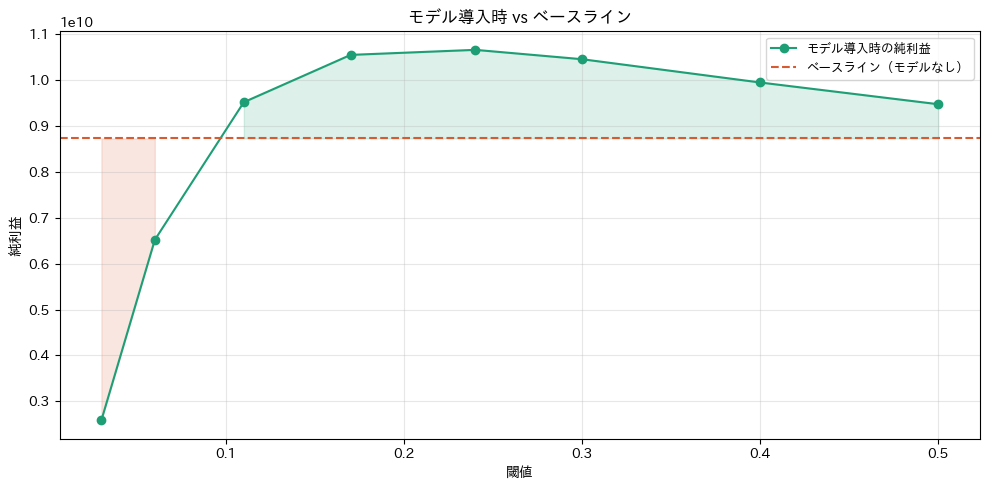

In [ ]:
#4-4　コスト試算　導入効果の可視化

fig, ax = plt.subplots(figsize=(10, 5))

x = results_df['threshold']

ax.plot(x, results_df['model_net'], marker='o', color='#1D9E75',
        label='モデル導入時の純利益', markersize=6)
ax.axhline(y=results_df['baseline_net'].iloc[0], color='#D85A30',
           linewidth=1.5, linestyle='--', label='ベースライン（モデルなし）')

ax.fill_between(x, results_df['model_net'], results_df['baseline_net'].iloc[0],
                where=results_df['model_net'] >= results_df['baseline_net'].iloc[0],
                alpha=0.15, color='#1D9E75')
ax.fill_between(x, results_df['model_net'], results_df['baseline_net'].iloc[0],
                where=results_df['model_net'] < results_df['baseline_net'].iloc[0],
                alpha=0.15, color='#D85A30')

ax.set_xlabel('閾値')
ax.set_ylabel('純利益')
ax.set_title('モデル導入時 vs ベースライン')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
#4-5　コスト試算　LGD感度分析

print("=== LGD感度分析（閾値=0.24固定、正常Precision≥95%） ===")
print(f"利益率={PROFIT_RATE:.0%} / 審査単価={REVIEW_COST:,}")
print()

lgd_values = [0.40, 0.50, 0.60, 0.70, 0.80]
sensitivity_results = []

for lgd in lgd_values:
    r = calc_business_impact(y, y_prob, amt_credit, 0.24, lgd, PROFIT_RATE, REVIEW_COST)
    baseline = amt_credit[y == 0].sum() * PROFIT_RATE - amt_credit[y == 1].sum() * lgd
    sensitivity_results.append({
        'LGD': f"{lgd:.0%}",
        'ベースライン純利益': f"{baseline:,.0f}",
        '貸倒防止額': f"{r['loss_prevented']:,.0f}",
        '残存貸倒損失': f"{r['loss_missed']:,.0f}",
        '機会損失': f"{r['opportunity_cost']:,.0f}",
        '審査コスト': f"{r['review_cost']:,.0f}",
        '純改善額': f"{r['improvement']:,.0f}",
        'ベースライン比': f"{r['improvement'] / baseline:+.1%}",
    })

print(pd.DataFrame(sensitivity_results).to_markdown(index=False))

=== LGD感度分析（閾値=0.24固定、正常Precision≥95%） ===
利益率=10% / 審査単価=1,000

| LGD   | ベースライン純利益   | 貸倒防止額    | 残存貸倒損失   | 機会損失      | 審査コスト   | 純改善額      | ベースライン比   |
|:------|:---------------------|:--------------|:---------------|:--------------|:-------------|:--------------|:-----------------|
| 40%   | 11,497,282,445       | 2,393,079,883 | 3,145,660,897  | 1,615,125,840 | 42,617,000   | 735,337,043   | +6.4%            |
| 50%   | 10,112,597,250       | 2,991,349,854 | 3,932,076,121  | 1,615,125,840 | 42,617,000   | 1,333,607,014 | +13.2%           |
| 60%   | 8,727,912,055        | 3,589,619,825 | 4,718,491,345  | 1,615,125,840 | 42,617,000   | 1,931,876,985 | +22.1%           |
| 70%   | 7,343,226,860        | 4,187,889,796 | 5,504,906,569  | 1,615,125,840 | 42,617,000   | 2,530,146,956 | +34.5%           |
| 80%   | 5,958,541,665        | 4,786,159,766 | 6,291,321,793  | 1,615,125,840 | 42,617,000   | 3,128,416,927 | +52.5%           |


【補足】  
LGD（未回収額の割合）が高いほど、モデル導入の純改善額が大きくなる。  
損失率が高い市場ほど、デフォルト検知の価値が高い。

In [ ]:
#5-1　閾値推奨と根拠
'''
■ 推奨閾値：0.24前後（正常Precision ≥ 95%ライン）

■ 根拠
  1. 自動承認率86%：2次審査を行う場合の業務量の大部分を自動化可能
  2. 正常Precision 95%：自動承認した中のデフォルト率を約5%に抑制
  3. 純改善額がプラス：LGD 40%以上で導入効果が成立（上記感度分析）
  4. 審査対象14%：人間審査のキャパシティとして現実的な水準

■ 閾値調整の指針
  - リスク許容度が低い企業 → 0.17（96%精度、審査率↑、見逃し↓）
  - コスト重視の企業       → 0.30（F1基準、自動化率↑）
  - 0.40以上は見逃しデフォルトが急増し、純改善額が低下するため非推奨

■ 運用上の留意点
  - 閾値は固定ではなく、定期的な再評価が必要
  - 新規データでのモデル再学習時に閾値も再最適化すべき
  - 審査単価の実測値が得られた段階で再試算を推奨
=================================================================
'''

'\n■ 推奨閾値：0.24前後（正常Precision ≥ 95%ライン）\n \n■ 根拠\n  1. 自動承認率86%：業務量の大部分を自動化可能\n  2. 正常Precision 95%：自動承認した中のデフォルト率を約5%に抑制\n  3. 純改善額がプラス：LGD 40%以上で導入効果が成立（上記感度分析）\n  4. 審査対象14%：人間審査のキャパシティとして現実的な水準\n \n■ 閾値調整の指針\n  - リスク許容度が低い企業 → 0.17（96%精度、審査率↑、見逃し↓）\n  - コスト重視の企業       → 0.30（F1基準、自動化率↑）\n  - 0.40以上は機会損失が急増するため非推奨\n \n■ 運用上の留意点\n  - 閾値は固定ではなく、定期的な再評価が必要\n  - 新規データでのモデル再学習時に閾値も再最適化すべき\n  - 審査単価の実測値が得られた段階で再試算を推奨\n=================================================================\n'

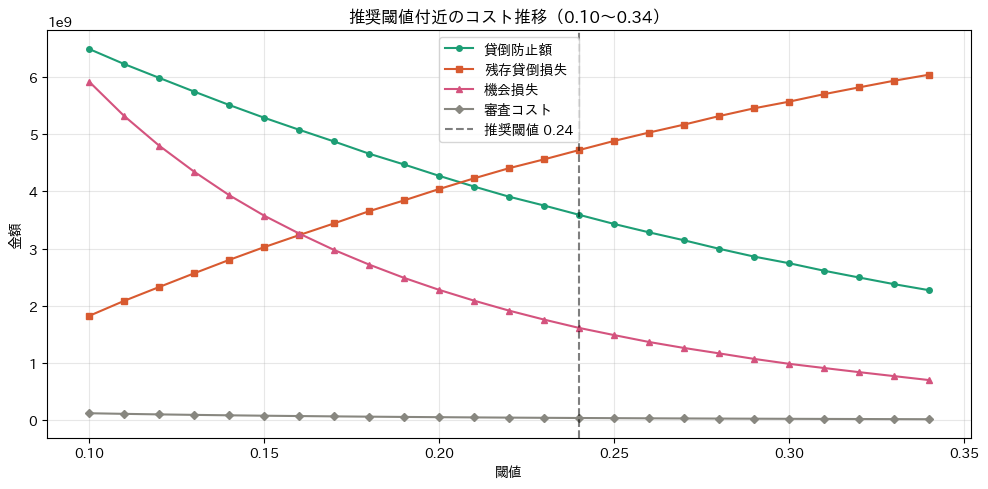

|   閾値 | 正常Precision   | 自動承認率(%)   | 貸倒防止額    | 残存貸倒損失   | 機会損失      | 純改善額      | ベースライン比   |
|-------:|:----------------|:----------------|:--------------|:---------------|:--------------|:--------------|:-----------------|
|   0.1  | 97.36%          | 59.1%           | 6,483,255,463 | 1,824,855,707  | 5,913,172,777 | 444,444,686   | +5.1%            |
|   0.11 | 97.14%          | 62.6%           | 6,220,982,415 | 2,087,128,755  | 5,314,766,193 | 791,218,222   | +9.1%            |
|   0.12 | 96.94%          | 65.7%           | 5,979,691,102 | 2,328,420,068  | 4,796,441,247 | 1,077,731,855 | +12.3%           |
|   0.13 | 96.75%          | 68.4%           | 5,740,239,752 | 2,567,871,418  | 4,342,311,978 | 1,300,864,774 | +14.9%           |
|   0.14 | 96.56%          | 70.9%           | 5,506,762,258 | 2,801,348,912  | 3,932,420,885 | 1,484,921,373 | +17.0%           |
|   0.15 | 96.38%          | 73.2%           | 5,283,884,389 | 3,024,226,781  | 3,574,892,634 | 1,626,438,755 | +18.6%

In [ ]:
#5-2　閾値推奨　推奨閾値付近の詳細比較

# 推奨閾値付近の細かい刻み
fine_thresholds = np.arange(0.10, 0.35, 0.01)
fine_results = [calc_business_impact(y, y_prob, amt_credit, t, LGD, PROFIT_RATE, REVIEW_COST) for t in fine_thresholds]
fine_df = pd.DataFrame(fine_results)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(fine_df['threshold'], fine_df['loss_prevented'], marker='o', label='貸倒防止額', color='#1D9E75', markersize=4)
ax.plot(fine_df['threshold'], fine_df['loss_missed'], marker='s', label='残存貸倒損失', color='#D85A30', markersize=4)
ax.plot(fine_df['threshold'], fine_df['opportunity_cost'], marker='^', label='機会損失', color='#D4537E', markersize=4)
ax.plot(fine_df['threshold'], fine_df['review_cost'], marker='D', label='審査コスト', color='#888780', markersize=4)
ax.axvline(x=0.24, color='black', linestyle='--', alpha=0.5, label='推奨閾値 0.24')

ax.set_xlabel('閾値')
ax.set_ylabel('金額')
ax.set_title('推奨閾値付近のコスト推移（0.10〜0.34）')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# テーブル出力
fine_display = fine_df[['threshold', 'normal_precision', 'auto_approve_rate', 'loss_prevented', 'loss_missed', 'opportunity_cost', 'improvement']].copy()
fine_display.columns = ['閾値', '正常Precision', '自動承認率(%)', '貸倒防止額', '残存貸倒損失', '機会損失', '純改善額']
fine_display['正常Precision'] = fine_display['正常Precision'].apply(lambda x: f"{x:.2%}")
fine_display['自動承認率(%)'] = fine_display['自動承認率(%)'].apply(lambda x: f"{x:.1f}%")
fine_display['ベースライン比'] = fine_df['improvement'].apply(
    lambda x: f"{x / fine_df['baseline_net'].iloc[0]:+.1%}")
for col in ['貸倒防止額', '残存貸倒損失', '機会損失', '純改善額']:
    fine_display[col] = fine_display[col].apply(lambda x: f"{x:,.0f}")
print(fine_display.to_markdown(index=False))

まとめ  


*   最適な閾値、正常プレシジョン  
正常プレシジョン98%以上はデフォルトリスクは低いものの、金額としてはモデルなしで貸付を行うよりも悪化し、ベースライン比-25%以上となる。  
最も改善度が高い箇所は閾値0.23、正常プレシジョン値95.15%の値であり、ベースライン(モデルなし)比+22.3%となった。   
この点については正常プレシジョンの要求を高めると自動承認件数が減少し、計算式上のTN（自動承認の利益）が小さくなるため、改善率は低下する。人間の2次審査でFP（誤検知）を救済すれば利益は回復しうるが、その比重が大きくなるほどモデル導入の意義は薄れる。   
また、当該モデルの実装による副次的効果として、判定が困難な申請を自動スクリーニングを用いて対象となる事例を絞ることで判断する人材の育成、研究の促進に繋がる。
  
【リスクと限界】  
■ データ上の制約  
  1. 通貨単位不明  
     金額ベースの絶対的な判断は困難。  
     パラメータを実データに置き換えた際の再試算が必須。  
     特に審査1件あたりの人的コストについては注視が必要。  
  2. 単一時点のデータ  
     時系列的な変動（景気変動、季節性）を
     捉えていない。本番運用ではモデルのドリフト監視が必要。
  3. 督促・回収コスト  
     デフォルト後の間接費用（督促人件費、
     法的手続き費用等）はデータに含まれず、実際の損失は
     LGD × AMT_CREDIT より大きい可能性がある。  

■ モデル上のリスク  
  1. ORGANIZATION_TYPE（勤務先業種）の過学習リスク  
     SHAP分析でばらつきが大きく、サンプル数の偏りにより
     特定業種への判定が不安定になる可能性がある。  
     対策案：低サンプル業種の統合、または同カラムの除外
  2. EXT_SOURCE依存  
     SHAP TOP3のうち2つがEXT_SOURCE由来。   
     外部スコアの提供元が変更・停止した場合の影響が大きい。
     対策案：EXT_SOURCE除外時のAUC低下幅を事前に検証
  3. 不均衡データ（デフォルト率8.07%）   
     閾値設定によるPrecision/Recallのトレードオフが大きく、
     運用環境でのデフォルト率が変動した場合に再調整が必要。  

■ 運用上の留意点  
  1. 人間審査の品質  
     モデルが審査に回した案件のうち、
     人間がどの程度正確に判定できるかは別途検証が必要。  
  2. 公平性  
     CODE_GENDER等の属性がモデルに含まれており、
     公平性の観点での検証は今回のスコープ外。  
  3. モデルの定期更新  
     少なくとも半年〜1年ごとの再学習を推奨。  

